# Calculate geometric eigenmodes

As outlined in in [Pang *et al.* (2023)](https://doi.org/10.1038/s41586-023-06098-1), the geometric
 eigenmodes of a brain structure can be obtained by solving the Laplace-Beltrami eigenvalue problem,

$$
\displaystyle \Delta\Psi = -\Lambda\Psi,
$$
 
 where:
 - $\Delta$ denotes the Laplace-Beltrami operator
 - $\Psi$ denotes the set of eigenmodes $\{\psi _1, \psi _2, ...\}$, ordered in ascending spatial frequency
 - $\Lambda$ denotes the set of eigenvalues $\{\lambda _1, \lambda _2, ...\}$, ordered in increasing value

In representing a brain structure as a discrete mesh of $N$ vertices, the above relation becomes a
 generalized eigenvalue problem,

$$
\displaystyle K\Psi = -M\Psi\Lambda,
$$

 where $K$ and $M$ denote the mass and stiffness matrices used by the Finite Element Method.

To calculate geometric eigenmodes of the cortex, we will first initialise an `EigenSolver` with a
 triangular surface mesh and medial wall mask. Since `neuromodes` includes these for human, macaque,
 and marmoset cortices, we can provide them as follows:

In [1]:
from importlib.resources import as_file, files
import os

import matplotlib.pyplot as plt
from nsbutils.plotting import plot_surf

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf, fetch_example_vol


In [2]:
# Load cortical surface mesh
surf, medmask = fetch_example_surf()

# Initialise solver with surface
solver = EigenSolver(surf, mask=medmask)

Note that by default, `fetch_example_surf` will load the human left hemisphere fsLR-32k midthickness
surface.

Next, we can compute eigenmodes and eigenvalues:

In [3]:
solver.solve(100)
print(solver)

EigenSolver
-----------
Surface mesh: 29696 vertices (2796 others masked out), 59147 triangles
Mass matrix: consistent
Stiffness matrix: homogeneous
Eigenmodes and eigenvalues: 100 computed



Note that we specified the first 100 eigenmodes and eigenvalues, which are then stored in the
 `emodes` and `evals` attributes. To visualize the modes, we can first add our medial wall back in
 via `unmask_data`, then pass a few modes to a plotter, such as `plot_surf` from our sister package
 `nsbutils`:

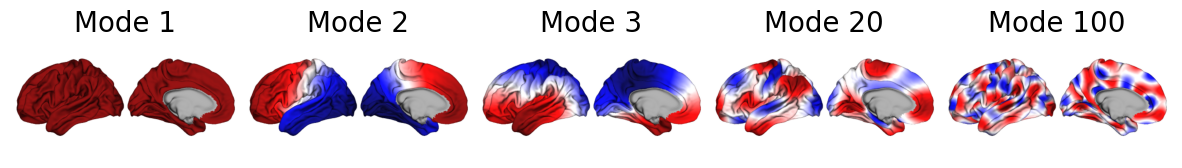

In [4]:
modes_unmasked = solver.unmask_data(solver.emodes)

lh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
with as_file(lh_surfpath) as lh_surfpath:
    plot_surf(lh_surfpath, modes_unmasked[:,[0,1,2,19,99]], labels=['Mode 1', 'Mode 2', 'Mode 3', 'Mode 20', 'Mode 100'], cmap='seismic_r')

Similarly, we can inspect the eigenvalue spectrum, which increases approximately linearly, in line
with analytical expectations:

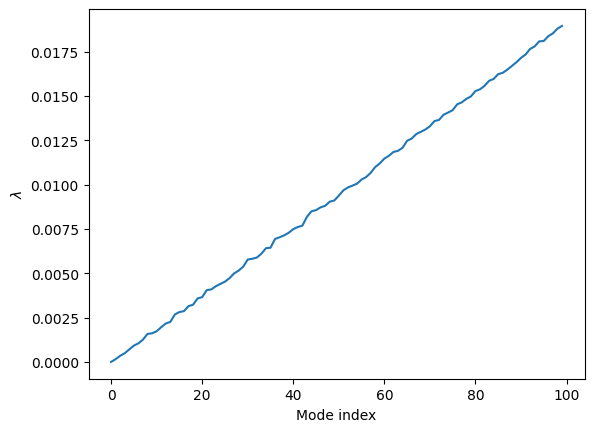

In [5]:
plt.plot(solver.evals)
plt.xlabel('Mode index')
plt.ylabel('$\\lambda$')
plt.show()

Now let's try computing eigenmodes and eigenvalues from a volume mesh, such as this representation
of the human hippocampus:

In [6]:
hippo = fetch_example_vol('hippocampus')

solver_hippo = EigenSolver(hippo)
solver_hippo.solve(100)
print(solver_hippo)

EigenSolver
-----------
Volume mesh: 1449 vertices, 5168 tetrahedra
Mass matrix: consistent
Stiffness matrix: homogeneous
Eigenmodes and eigenvalues: 100 computed


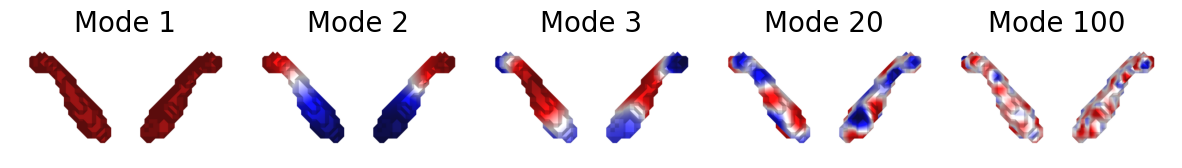

In [7]:
# Save surface boundary for plotting (NOTE: temporary, will be passed directly to future plotter)
hippo_bound = hippo.boundary_tria()
hippo_bound.write_gifti('hippo_bound.surf.gii')

# Plot
surfpath = files('neuromodes').parent / 'docs' / 'tutorials' / 'hippo_bound.surf.gii'
with as_file(surfpath) as surfpath:
    plot_surf(surfpath, solver_hippo.emodes[:,[0,1,2,19,99]], labels=['Mode 1', 'Mode 2', 'Mode 3', 'Mode 20', 'Mode 100'], cmap='seismic_r')

# Delete temporary file
os.remove('hippo_bound.surf.gii')

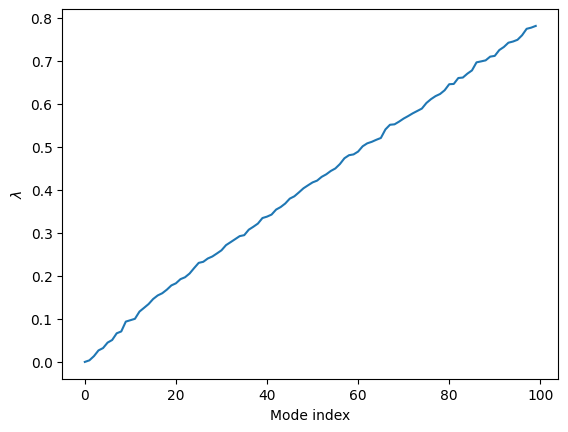

In [8]:
plt.plot(solver_hippo.evals)
plt.xlabel('Mode index')
plt.ylabel('$\\lambda$')
plt.show()